In [1]:
import torch

import sys
sys.path.append("../")
from utils import Learner

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache() 
# pip install importlib-metadata warp-lang

dry_run = False
# dry_run=True
save = not dry_run
epochs = 5 if dry_run else 500
print_every = 1 if dry_run else 10

## NS_Heat

In [ ]:
from utils import MPData
data_name = 'NS_heat'
model_name= 'MDeepONet'
out_channels= 5 if data_name == 'MHD' else 3
mpdata = MPData(
    "/home/chieh/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.DeepONet import ShareTrunkDeepONet
from neuralop.utils import count_model_params
p = 4096
model = ShareTrunkDeepONet(p=p,out_channels=out_channels).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")


Our model has 28,945,859 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}')

total number of parameters: 28,945,859


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 10.30/0.35 | loss: 1.10e+00 | test: 4.48e-01 | norm: 0.54


epoch:10 | time: 10.01/0.35 | loss: 6.80e-02 | test: 1.02e-01 | norm: 0.24


epoch:20 | time: 10.02/0.35 | loss: 4.24e-02 | test: 4.57e-02 | norm: 0.12


epoch:30 | time: 10.01/0.35 | loss: 2.56e-02 | test: 3.44e-02 | norm: 0.09


epoch:40 | time: 9.99/0.35 | loss: 1.59e-02 | test: 1.68e-02 | norm: 0.05


...

epoch:480 | time: 10.02/0.35 | loss: 2.73e-03 | test: 2.77e-03 | norm: 0.00


epoch:490 | time: 10.02/0.35 | loss: 2.73e-03 | test: 2.76e-03 | norm: 0.00


epoch:499 | time: 10.02/0.35 | loss: 2.71e-03 | test: 2.76e-03 | norm: 0.00


Finish epoch:499 | train loss: 2.7127e-03 | test loss: 2.7588e-03
total train time : 5008.145


Channel Loss: var0: 1.3108e-03 var1: 1.1337e-03 var2: 3.1432e-04 



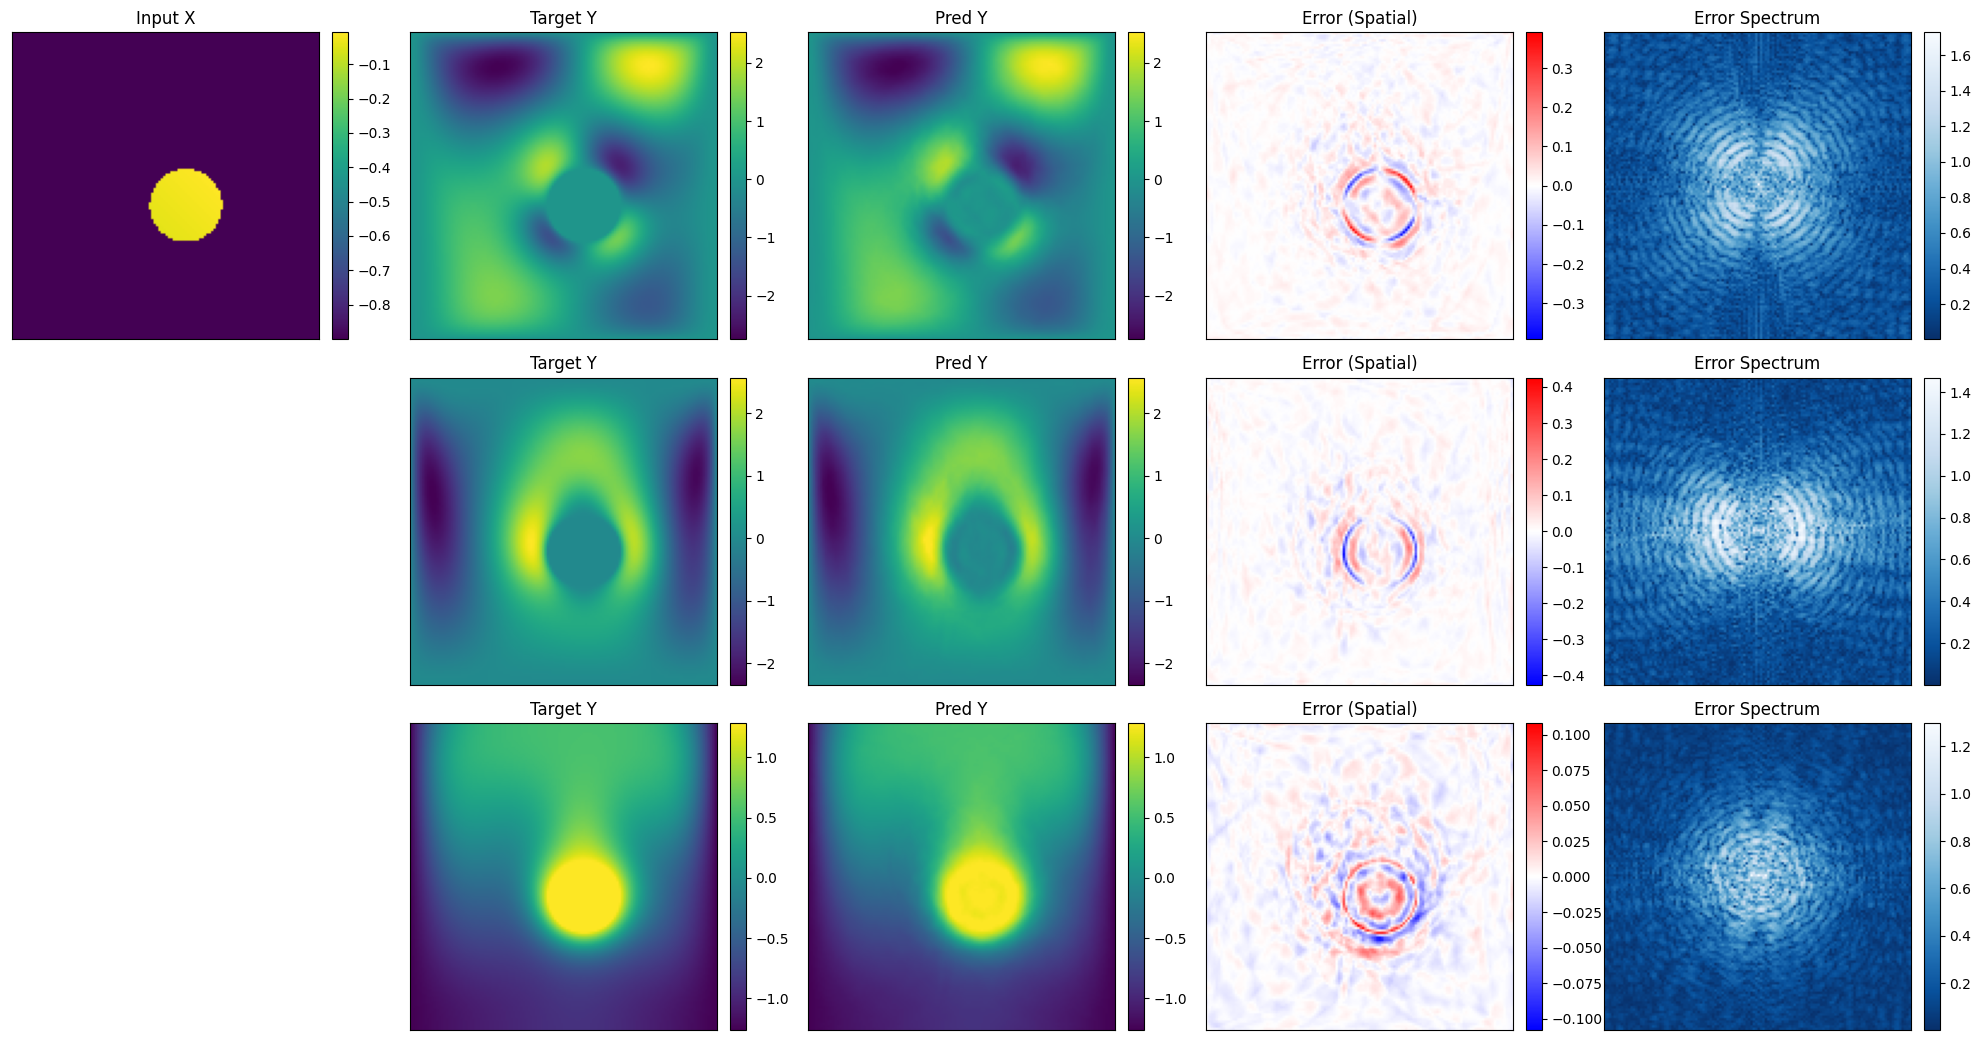

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

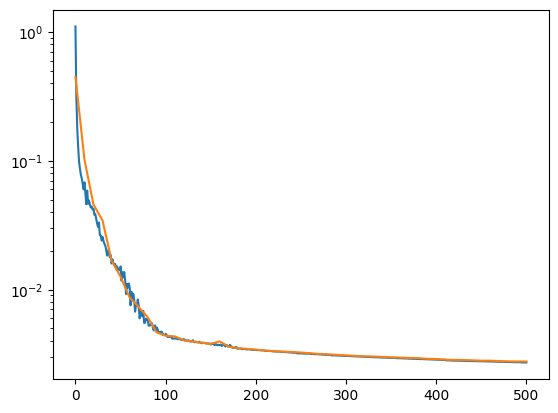

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## TE_Heat

In [ ]:
from utils import MPData
data_name = 'TE_heat'
model_name= 'MDeepONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.DeepONet import ShareTrunkDeepONet
from neuralop.utils import count_model_params
p=512
model = ShareTrunkDeepONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")


Our model has 12,398,531 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}')

total number of parameters: 12,398,531


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 3.52/0.13 | loss: 1.59e+00 | test: 1.40e+00 | norm: 0.25


epoch:10 | time: 3.53/0.13 | loss: 3.44e-01 | test: 3.45e-01 | norm: 0.22


epoch:20 | time: 3.52/0.13 | loss: 1.36e-01 | test: 1.00e-01 | norm: 0.16


epoch:30 | time: 3.52/0.13 | loss: 8.18e-02 | test: 1.39e-01 | norm: 0.16


epoch:40 | time: 3.53/0.13 | loss: 2.54e-02 | test: 1.78e-02 | norm: 0.07


...

epoch:470 | time: 3.53/0.13 | loss: 8.91e-04 | test: 8.67e-04 | norm: 0.00


epoch:480 | time: 3.53/0.13 | loss: 8.84e-04 | test: 8.60e-04 | norm: 0.00


epoch:490 | time: 3.53/0.13 | loss: 8.78e-04 | test: 8.54e-04 | norm: 0.00


epoch:499 | time: 3.53/0.13 | loss: 8.71e-04 | test: 8.48e-04 | norm: 0.00


Finish epoch:499 | train loss: 8.7144e-04 | test loss: 8.4832e-04
total train time : 1763.005
Channel Loss: var0: 4.0058e-04 var1: 4.1211e-04 var2: 3.5632e-05 



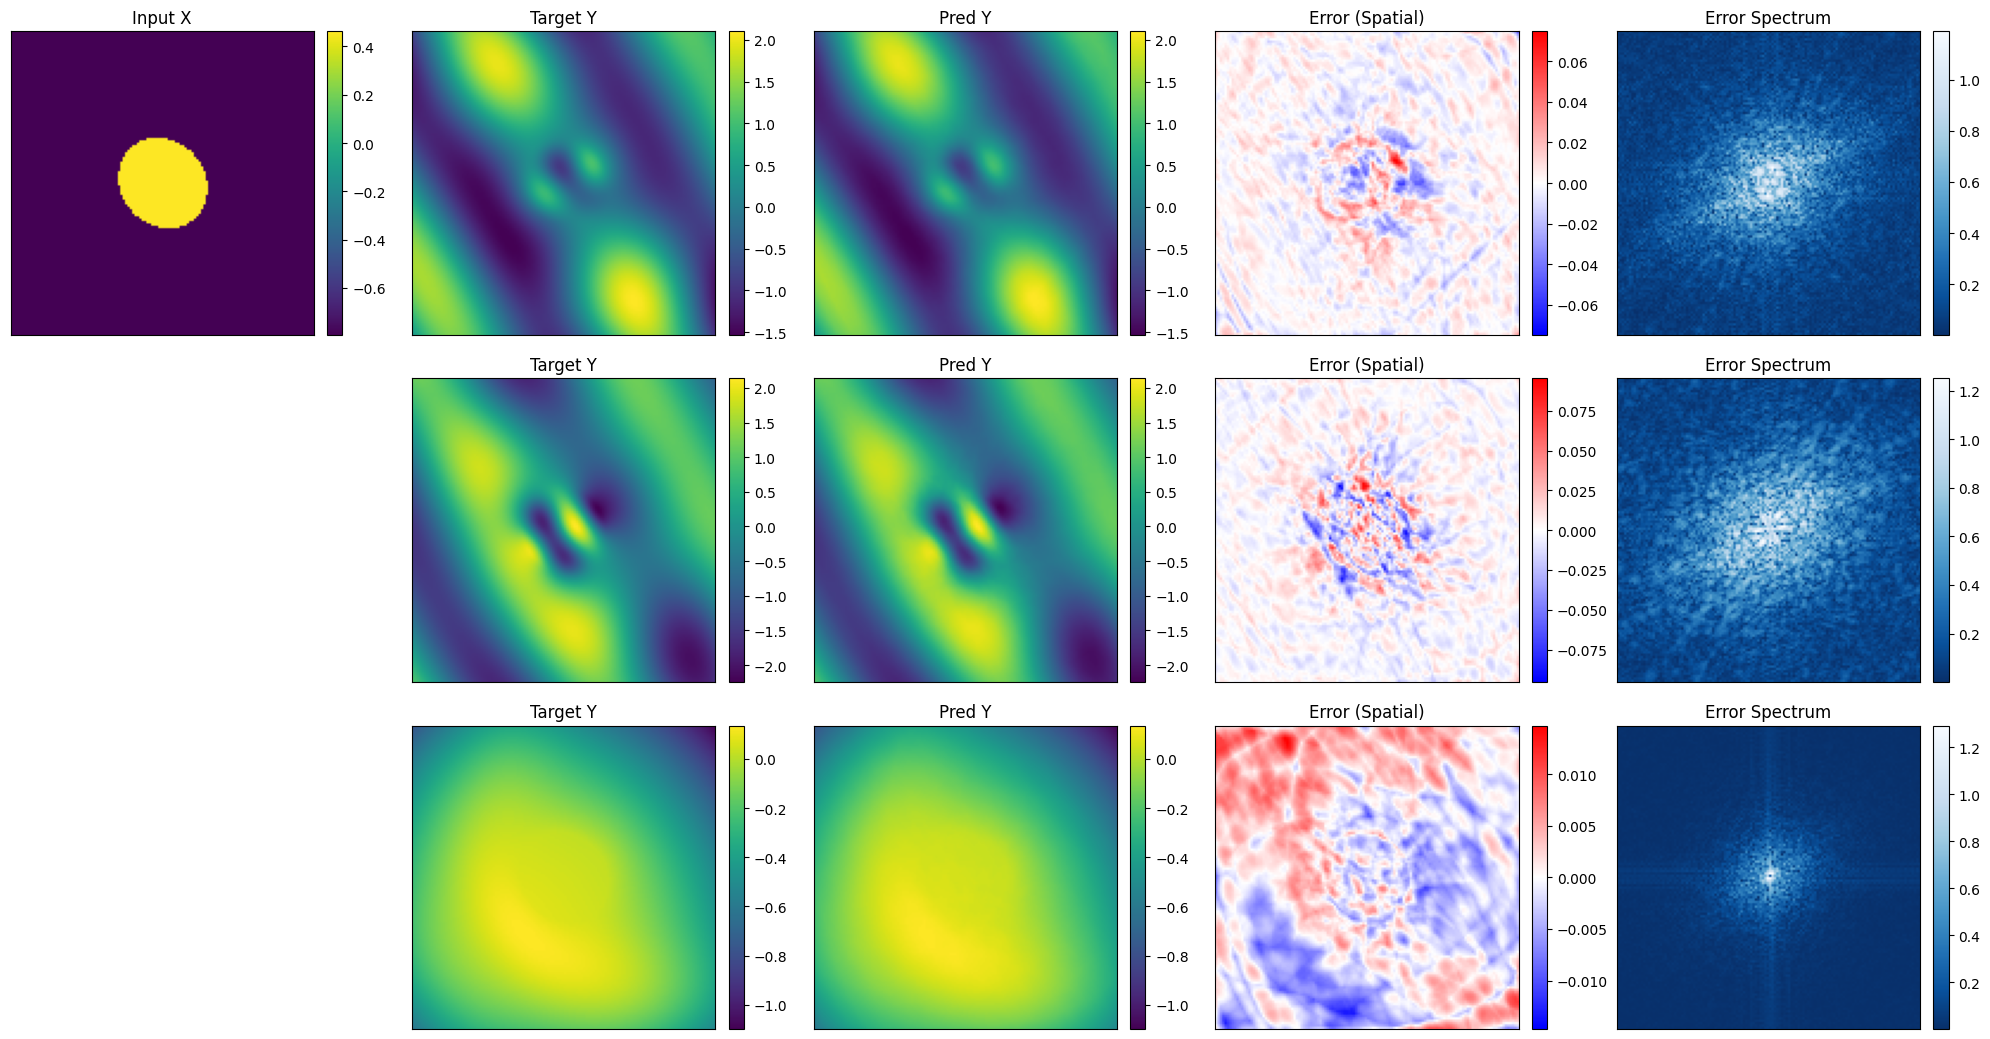

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

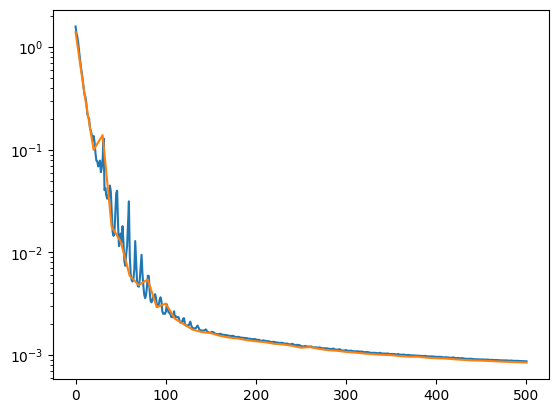

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## E_flow

In [ ]:
from utils import MPData
data_name = 'E_flow'
model_name= 'MDeepONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.DeepONet import ShareTrunkDeepONet
from neuralop.utils import count_model_params
p=256
model = ShareTrunkDeepONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")


Our model has 11,216,579 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}')

total number of parameters: 11,216,579


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 3.47/0.12 | loss: 1.54e+00 | test: 1.00e+00 | norm: 0.43


epoch:10 | time: 3.44/0.12 | loss: 3.39e-01 | test: 3.31e-01 | norm: 0.32


epoch:20 | time: 3.45/0.12 | loss: 2.50e-01 | test: 2.53e-01 | norm: 0.24


epoch:30 | time: 3.45/0.12 | loss: 2.18e-01 | test: 2.15e-01 | norm: 0.16


epoch:40 | time: 3.46/0.12 | loss: 1.99e-01 | test: 1.96e-01 | norm: 0.13


...

epoch:470 | time: 3.45/0.12 | loss: 1.01e-01 | test: 1.01e-01 | norm: 0.03


epoch:480 | time: 3.44/0.12 | loss: 1.01e-01 | test: 1.01e-01 | norm: 0.03


epoch:490 | time: 3.43/0.12 | loss: 1.01e-01 | test: 1.01e-01 | norm: 0.03


epoch:499 | time: 3.47/0.12 | loss: 1.01e-01 | test: 1.01e-01 | norm: 0.03


Finish epoch:499 | train loss: 1.0097e-01 | test loss: 1.0097e-01
total train time : 1725.825
Channel Loss: var0: 2.7486e-04 var1: 4.5411e-02 var2: 5.5285e-02 



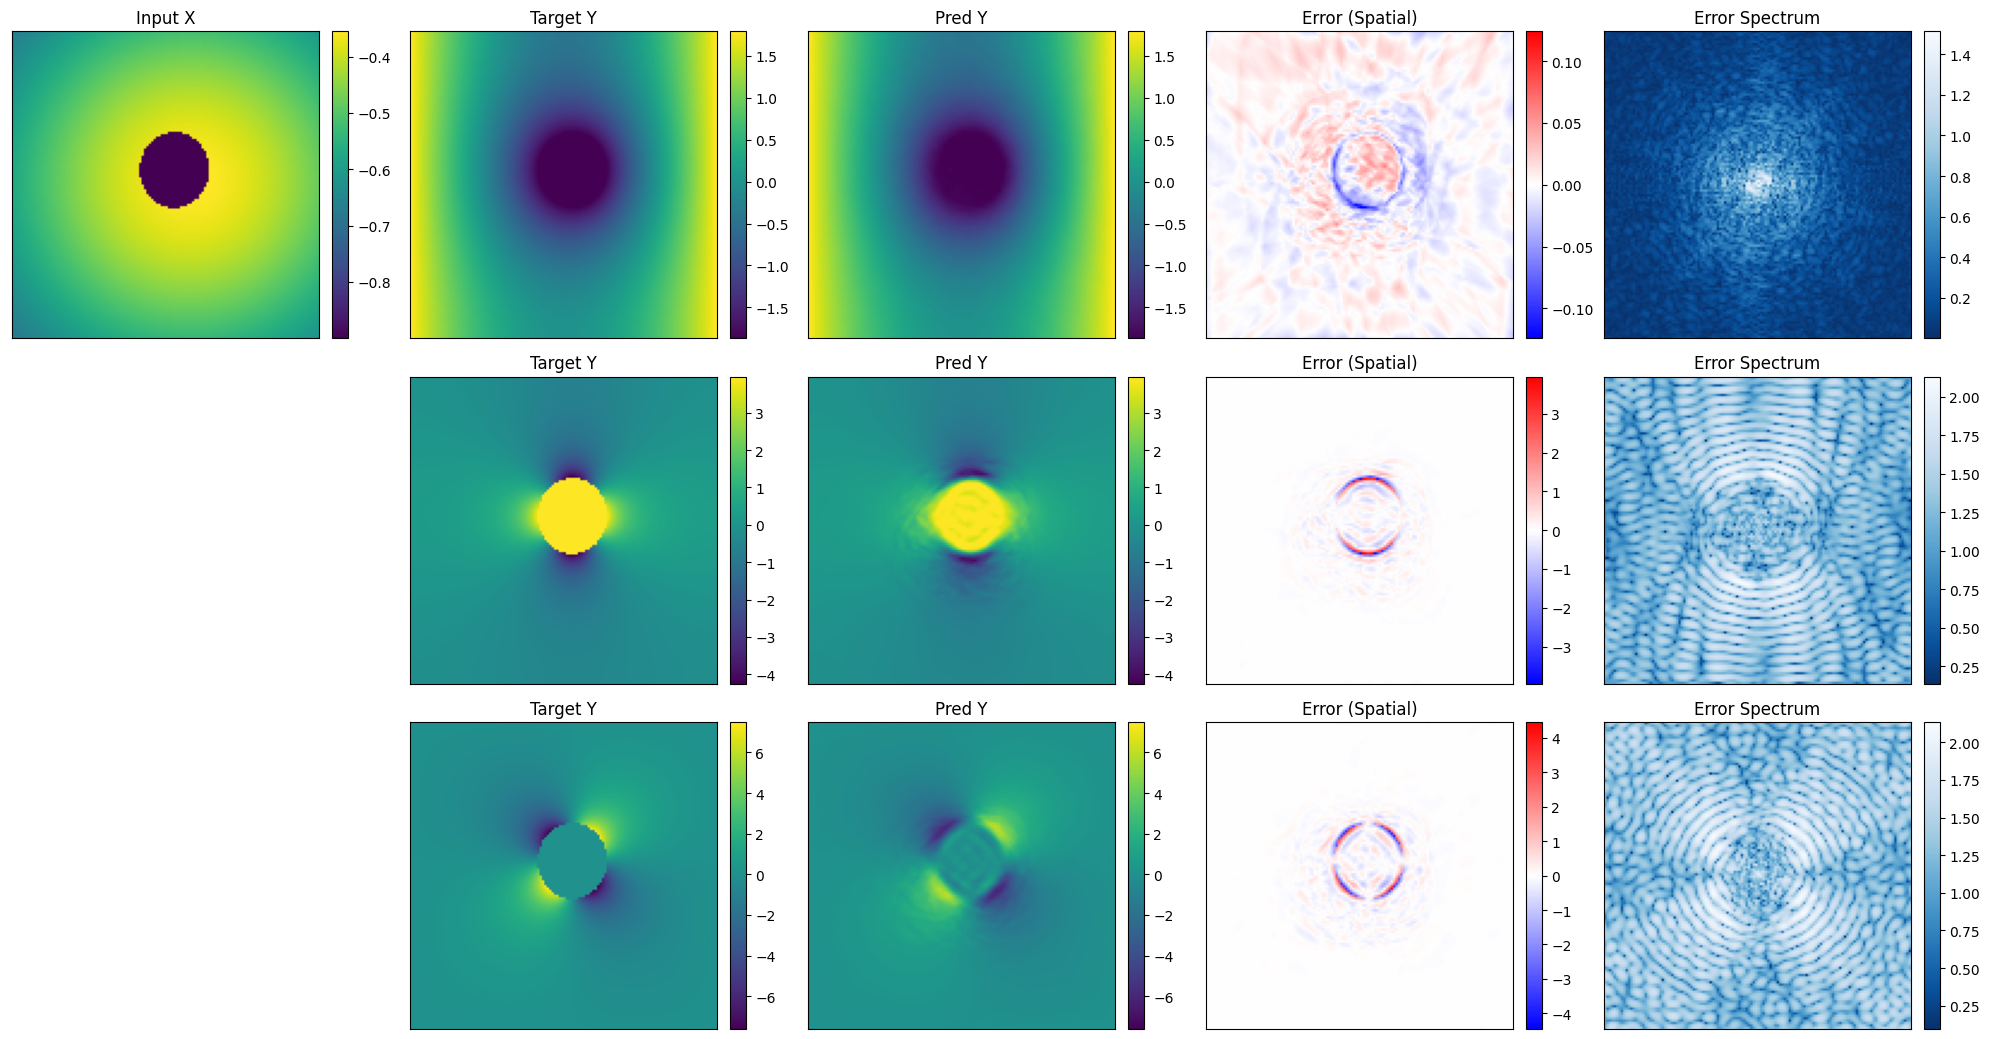

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

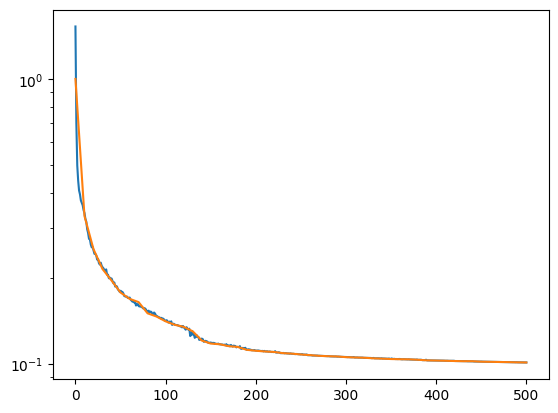

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## MHD

In [ ]:
from utils import MPData
data_name = 'MHD'
model_name = 'MDeepONet'
y_channels = 5

mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False
)
train_loader, test_loader = mpdata.loader()

Error: trying to import DISCO convolutions without optional dependency torch-harmonics.  Please install with `pip install torch-harmonics` and retry.


In [ ]:
from models.DeepONet import ShareTrunkDeepONet
from neuralop.utils import count_model_params
p = 512
model = ShareTrunkDeepONet(p=p, out_channels=y_channels).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")


Our model has 13,974,469 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}')

total number of parameters: 13,974,469


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 6.39/0.25 | loss: 2.41e+00 | test: 1.91e+00 | norm: 0.66


epoch:10 | time: 6.37/0.25 | loss: 1.71e-01 | test: 1.55e-01 | norm: 4.66


epoch:20 | time: 6.37/0.25 | loss: 1.06e-01 | test: 9.37e-02 | norm: 3.29


epoch:30 | time: 6.38/0.25 | loss: 8.07e-02 | test: 1.26e-01 | norm: 2.40


epoch:40 | time: 6.38/0.25 | loss: 6.43e-02 | test: 7.63e-02 | norm: 1.81


...

epoch:480 | time: 6.37/0.25 | loss: 2.66e-02 | test: 3.42e-02 | norm: 0.21


epoch:490 | time: 6.38/0.25 | loss: 2.66e-02 | test: 3.43e-02 | norm: 0.21


epoch:499 | time: 6.37/0.25 | loss: 2.65e-02 | test: 3.42e-02 | norm: 0.19


total train time : 3188.403
Channel Loss: 

var0: 1.1044e-03 var1: 1.3838e-03 var2: 3.1000e-02 var3: 2.1796e-04 var4: 4.6139e-04 



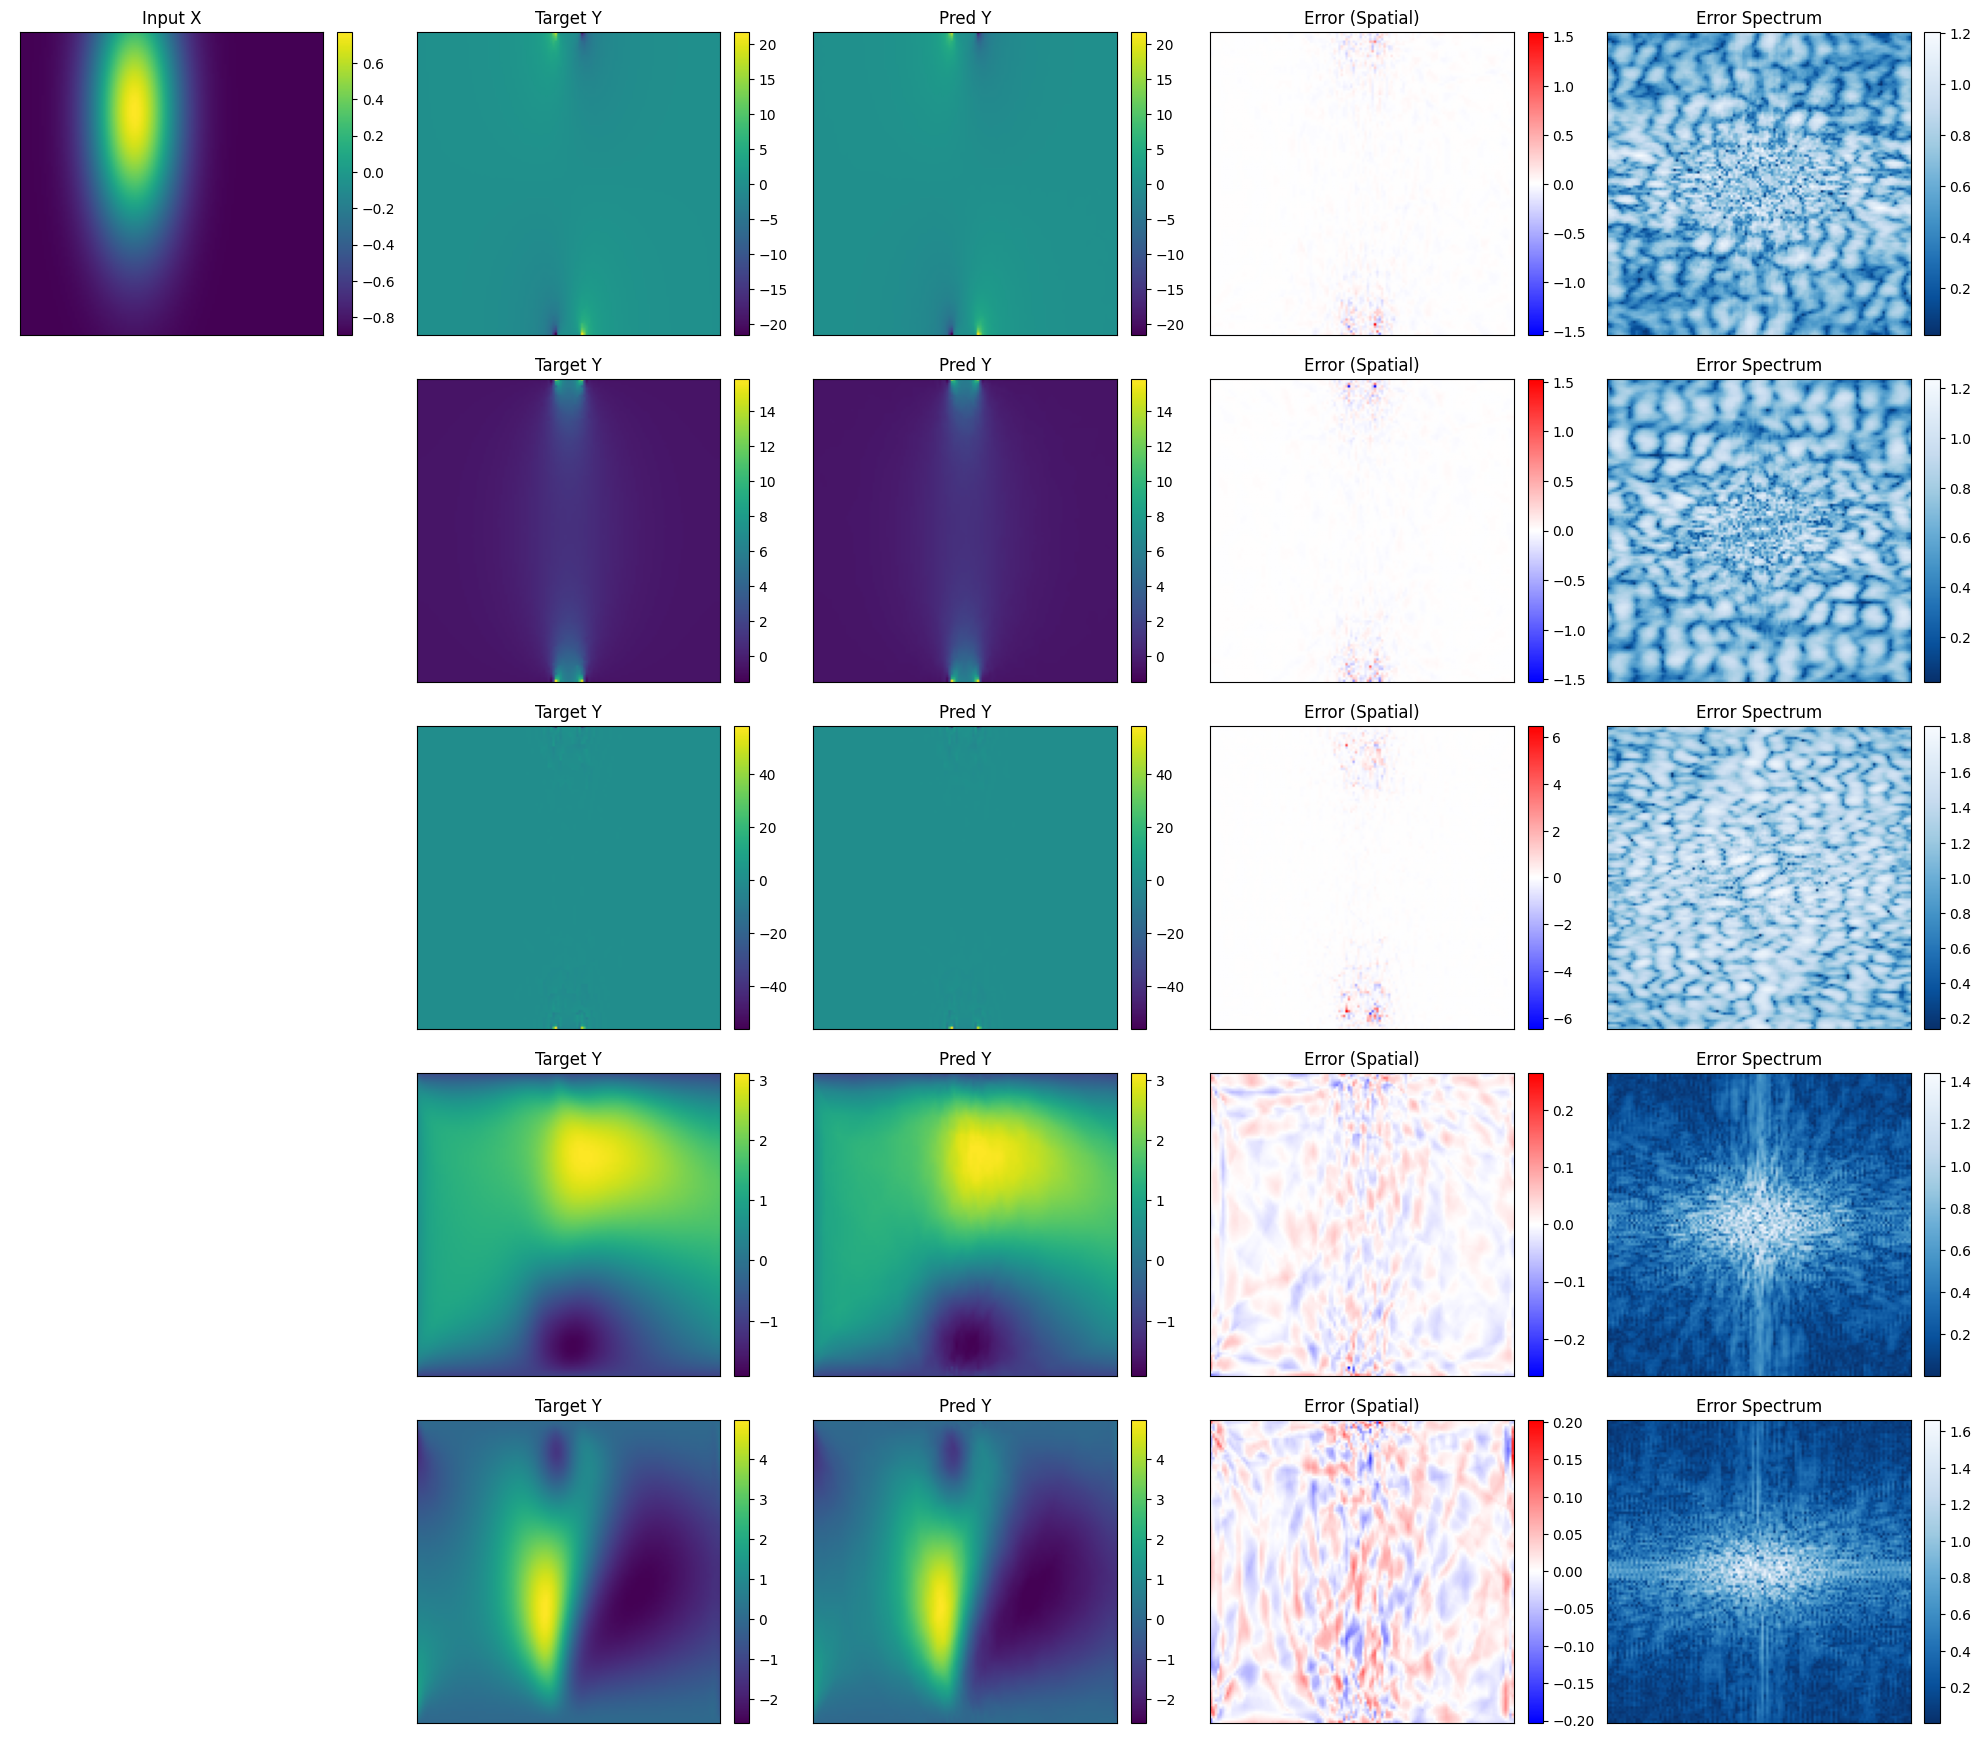

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=y_channels)

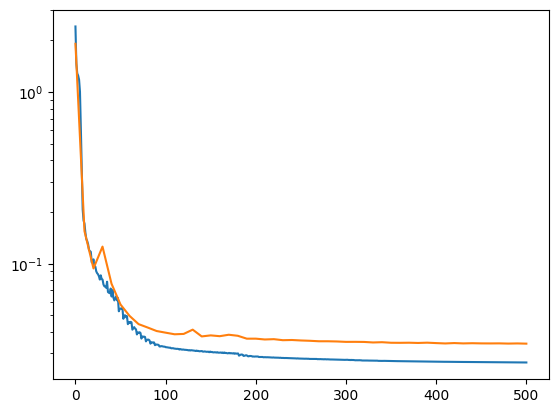

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')